Dataset saved as mnist_2features.csv


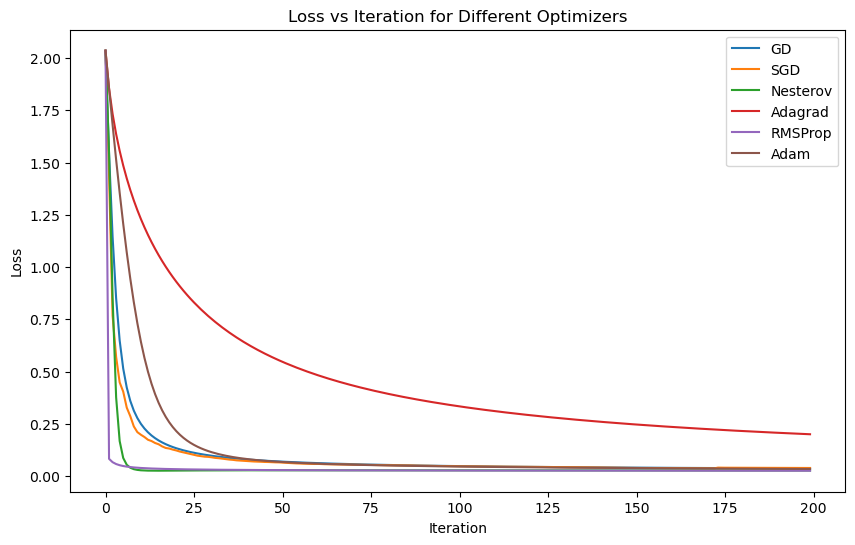

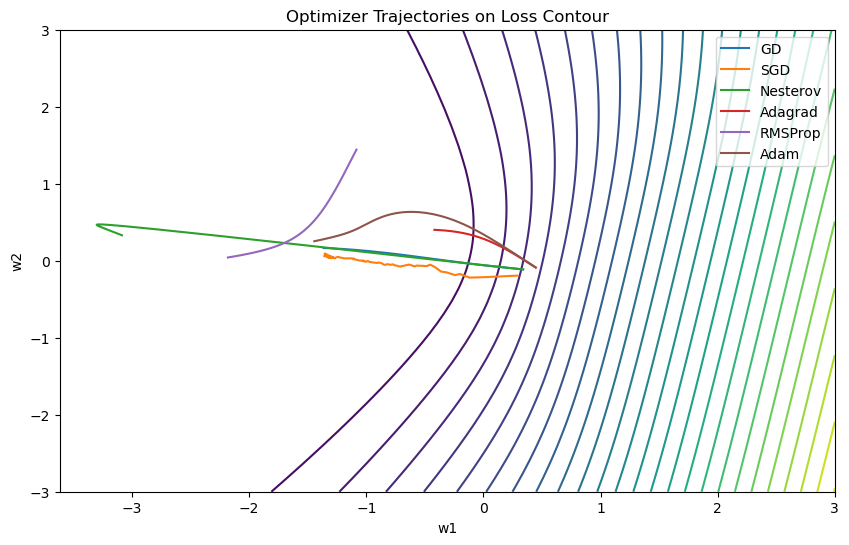

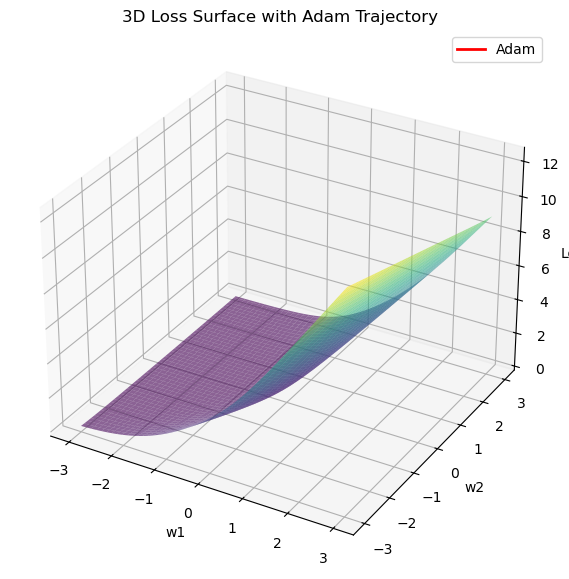

C:\Users\23adsb59\.conda\envs\61782323110059\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import mnist
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation


(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train_flat = x_train.reshape(len(x_train), -1) / 255.0
x_test_flat = x_test.reshape(len(x_test), -1) / 255.0


pca = PCA(n_components=2)
features_train = pca.fit_transform(x_train_flat)
features_test = pca.transform(x_test_flat)


mask_train = (y_train == 0) | (y_train == 1)
mask_test = (y_test == 0) | (y_test == 1)

X_train = features_train[mask_train]
y_train_bin = y_train[mask_train]

X_test = features_test[mask_test]
y_test_bin = y_test[mask_test]


df = pd.DataFrame(X_train, columns=['feature1', 'feature2'])
df['label'] = y_train_bin
df.to_csv('mnist_2features.csv', index=False)

print("Dataset saved as mnist_2features.csv")


def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y, y_pred):
    eps = 1e-10
    return -np.mean(y*np.log(y_pred+eps) + (1-y)*np.log(1-y_pred+eps))


class OptimizerExperiment:
    def __init__(self, X, y, lr=0.01, epochs=20):
        self.X = X
        self.y = y
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []
        self.w_history = []

    def run(self, optimizer="GD"):
        np.random.seed(42)
        w = np.random.randn(2)  # initial weights
        v = np.zeros_like(w)    # momentum
        s = np.zeros_like(w)    # RMSProp/Adam cache
        beta1, beta2 = 0.9, 0.999
        eps = 1e-8

        for t in range(1, self.epochs+1):
            z = np.dot(self.X, w)
            y_pred = sigmoid(z)
            loss = binary_cross_entropy(self.y, y_pred)
            grad = np.dot(self.X.T, (y_pred - self.y)) / len(self.y)

            # Optimizer rules
            if optimizer == "GD":
                w -= self.lr * grad
            elif optimizer == "SGD":
                idx = np.random.randint(len(self.X))
                xi, yi = self.X[idx], self.y[idx]
                grad = (sigmoid(np.dot(xi, w)) - yi) * xi
                w -= self.lr * grad
            elif optimizer == "Nesterov":
                lookahead = w - beta1 * v
                grad = np.dot(self.X.T, (sigmoid(np.dot(self.X, lookahead)) - self.y)) / len(self.y)
                v = beta1 * v + self.lr * grad
                w -= v
            elif optimizer == "Adagrad":
                s += grad**2
                w -= self.lr * grad / (np.sqrt(s) + eps)
            elif optimizer == "RMSProp":
                s = beta2 * s + (1-beta2) * grad**2
                w -= self.lr * grad / (np.sqrt(s) + eps)
            elif optimizer == "Adam":
                v = beta1 * v + (1-beta1) * grad
                s = beta2 * s + (1-beta2) * grad**2
                v_corr = v / (1-beta1**t)
                s_corr = s / (1-beta2**t)
                w -= self.lr * v_corr / (np.sqrt(s_corr) + eps)

            self.loss_history.append(loss)
            self.w_history.append(w.copy())

        return np.array(self.w_history), np.array(self.loss_history)


optimizers = ["GD", "SGD", "Nesterov", "Adagrad", "RMSProp", "Adam"]
results = {}

for opt in optimizers:
    exp = OptimizerExperiment(X_train, y_train_bin, lr=0.05, epochs=200)
    w_hist, loss_hist = exp.run(optimizer=opt)
    results[opt] = (w_hist, loss_hist)



plt.figure(figsize=(10,6))
for opt in optimizers:
    plt.plot(results[opt][1], label=opt)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iteration for Different Optimizers")
plt.legend()
plt.show()


w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)
loss_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        z = X_train @ np.array([W1[i,j], W2[i,j]])
        loss_surface[i,j] = binary_cross_entropy(y_train_bin, sigmoid(z))

plt.figure(figsize=(10,6))
plt.contour(W1, W2, loss_surface, levels=30)
for opt in optimizers:
    w_hist = results[opt][0]
    plt.plot(w_hist[:,0], w_hist[:,1], label=opt)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Optimizer Trajectories on Loss Contour")
plt.legend()
plt.show()



w1 = np.linspace(-3, 3, 100)
w2 = np.linspace(-3, 3, 100)
W1, W2 = np.meshgrid(w1, w2)
loss_surface = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        z = X_train @ np.array([W1[i,j], W2[i,j]])
        loss_surface[i,j] = binary_cross_entropy(y_train_bin, sigmoid(z))


def animate_optimizer(opt_name, w_hist):
    fig = plt.figure(figsize=(10,7))
    ax = fig.add_subplot(111, projection='3d')

    
    ax.plot_surface(W1, W2, loss_surface, cmap='viridis', alpha=0.6)

    
    line, = ax.plot([], [], [], 'r-', lw=2, label=opt_name)
    point, = ax.plot([], [], [], 'ro')

    
    ax.set_xlabel("w1")
    ax.set_ylabel("w2")
    ax.set_zlabel("Loss")
    ax.set_title(f"3D Loss Surface with {opt_name} Trajectory")

    
    def update(frame):
        w = w_hist[:frame]
        z_vals = [binary_cross_entropy(y_train_bin, sigmoid(X_train @ wi)) for wi in w]
        line.set_data(w[:,0], w[:,1])
        line.set_3d_properties(z_vals)
        point.set_data(w[-1,0], w[-1,1])
        point.set_3d_properties(z_vals[-1])
        return line, point

    ani = FuncAnimation(fig, update, frames=len(w_hist), interval=100, blit=False)
    plt.legend()
    plt.show()


w_hist, _ = results["Adam"]
animate_optimizer("Adam", w_hist)
